# TP Individual - Leticia L. Rodriguez - 12/9/2026 - EDA

## Descarga del Dataset

Usando Dataset: https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency

In [1]:
import numpy as np
from scipy.stats import entropy
import sys
import os
import missingno as msno

In [2]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.plotting import plot_histograma

In [3]:
!pip install kaggle

In [4]:
# 1. Instala la librería si no la tienes
import os
import pandas as pd 



os.makedirs('data', exist_ok=True)

# 2. Descarga y descomprime
!kaggle datasets download -d equilibriumm/sleep-efficiency
! mv sleep-efficiency.zip data
!unzip data/sleep-efficiency.zip 



Dataset URL: https://www.kaggle.com/datasets/equilibriumm/sleep-efficiency
License(s): copyright-authors
100%|█████████████████████████████████████| 8.94k/8.94k [00:00<00:00, 14.8MB/s]

Archive:  data/sleep-efficiency.zip
  inflating: Sleep_Efficiency.csv    


In [104]:

# 3. Carga los datos en Pandas
import pandas as pd
df = pd.read_csv('Sleep_Efficiency.csv')

In [6]:

print("Vista General del Dataset")
df.head(20)

Vista General del Dataset


,ID,Age,Gender,Bedtime,Wakeup time,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Smoking status,Exercise frequency
0,1,65,Female,2021-03-06 01:00:00,2021-03-06 07:00:00,6.0,0.88,18,70,12,0.0,0.0,0.0,Yes,3.0
1,2,69,Male,2021-12-05 02:00:00,2021-12-05 09:00:00,7.0,0.66,19,28,53,3.0,0.0,3.0,Yes,3.0
2,3,40,Female,2021-05-25 21:30:00,2021-05-25 05:30:00,8.0,0.89,20,70,10,1.0,0.0,0.0,No,3.0
3,4,40,Female,2021-11-03 02:30:00,2021-11-03 08:30:00,6.0,0.51,23,25,52,3.0,50.0,5.0,Yes,1.0
4,5,57,Male,2021-03-13 01:00:00,2021-03-13 09:00:00,8.0,0.76,27,55,18,3.0,0.0,3.0,No,3.0
5,6,36,Female,2021-07-01 21:00:00,2021-07-01 04:30:00,7.5,0.90,23,60,17,0.0,NaN,0.0,No,1.0
6,7,27,Female,2021-07-21 21:00:00,2021-07-21 03:00:00,6.0,0.54,28,25,47,2.0,50.0,0.0,Yes,1.0
7,8,53,Male,2021-08-16 00:30:00,2021-08-16 10:30:00,10.0,0.90,28,52,20,0.0,50.0,0.0,Yes,3.0
8,9,41,Female,2021-04-05 02:30:00,2021-04-05 08:30:00,6.0,0.79,28,55,17,3.0,50.0,0.0,No,1.0
9,10,11,Female,2021-09-16 01:00:00,2021-09-16 10:00:00,9.0,0.55,18,37,45,4.0,0.0,0.0,No,0.0


## Columnas y tipos de datos

In [7]:
tam = df.shape
print("Registros: ", tam[0], "Columnas: ", tam[1])

Registros:  452 Columnas:  15


In [8]:
# Listar features y columnas
df.columns

Index(['ID', 'Age', 'Gender', 'Bedtime', 'Wakeup time', 'Sleep duration',
       'Sleep efficiency', 'REM sleep percentage', 'Deep sleep percentage',
       'Light sleep percentage', 'Awakenings', 'Caffeine consumption',
       'Alcohol consumption', 'Smoking status', 'Exercise frequency'],
      dtype='str')

In [9]:
# Tipos de datos de las columnas
df.dtypes

ID                          int64
Age                         int64
Gender                        str
Bedtime                       str
Wakeup time                   str
Sleep duration            float64
Sleep efficiency          float64
REM sleep percentage        int64
Deep sleep percentage       int64
Light sleep percentage      int64
Awakenings                float64
Caffeine consumption      float64
Alcohol consumption       float64
Smoking status                str
Exercise frequency        float64
dtype: object

In [10]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      452 non-null    int64  
 1   Age                     452 non-null    int64  
 2   Gender                  452 non-null    str    
 3   Bedtime                 452 non-null    str    
 4   Wakeup time             452 non-null    str    
 5   Sleep duration          452 non-null    float64
 6   Sleep efficiency        452 non-null    float64
 7   REM sleep percentage    452 non-null    int64  
 8   Deep sleep percentage   452 non-null    int64  
 9   Light sleep percentage  452 non-null    int64  
 10  Awakenings              432 non-null    float64
 11  Caffeine consumption    427 non-null    float64
 12  Alcohol consumption     438 non-null    float64
 13  Smoking status          452 non-null    str    
 14  Exercise frequency      446 non-null    float64
dtype

## Variables Categóricas



In [11]:
variables_categoricas = ['Gender','Smoking status']
df['Gender'] = df['Gender'].astype('category')
df['Smoking status'] = df['Smoking status'].astype('category')
df.describe(include='category')

,Gender,Smoking status
count,452,452
unique,2,2
top,Male,No
freq,228,298


In [12]:
# FRecuencia por tegoria

for v in variables_categoricas:
    print(f"\nFrecuencias de la variable {v}: \n{df[v].value_counts()}")


Frecuencias de la variable Gender: 
Gender
Male      228
Female    224
Name: count, dtype: int64

Frecuencias de la variable Smoking status: 
Smoking status
No     298
Yes    154
Name: count, dtype: int64


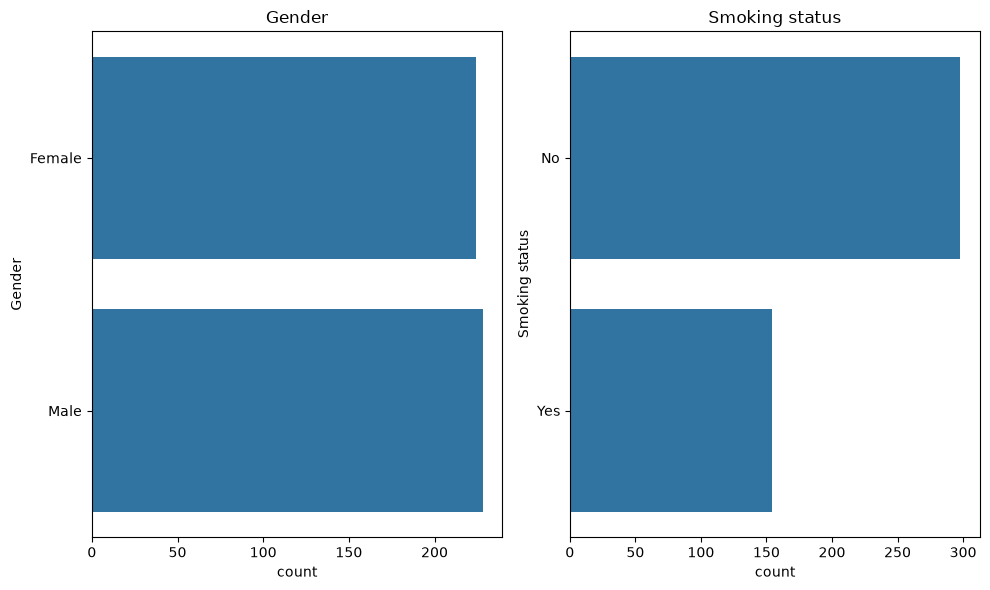

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 2, figsize=(10, 6))

for i in range(2):
    var = variables_categoricas[i]
    sns.countplot(y=var, data=df, ax=ax[i])
    ax[i].set_title(var)

plt.tight_layout()
plt.show()


### Entropía

In [14]:
# Calculamos entropía

for i in range(2):
    var = variables_categoricas[i]
    var_counts = df[var].value_counts() # Cuento ocurrencias de cada categoría
    var_pi = var_counts / var_counts.sum() # Calculo las pi (frecuencias relativas)
    
    # Entropía máxima (si todas las categorías ocurrieran con la misma probabilidad)
    H_max = np.log2(df[var].nunique())
    
    # Entropía de Shannon con Scipi
    H_Shannon = entropy(var_pi, base=2)
    print(f"Variable: {var} Entropía H: {H_Shannon:.2f} - Entropia máxima H_max: {H_max:.2f}")


Variable: Gender Entropía H: 1.00 - Entropia máxima H_max: 1.00
Variable: Smoking status Entropía H: 0.93 - Entropia máxima H_max: 1.00


# Variables numéricas: estadística descriptiva


In [15]:
df.describe()

,ID,Age,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Exercise frequency
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,446.000000
mean,226.500000,40.285398,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,1.791480
std,130.625419,13.172250,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,1.428134
min,1.000000,9.000000,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,113.750000,29.000000,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,0.000000
50%,226.500000,40.000000,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,2.000000
75%,339.250000,52.000000,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,3.000000
max,452.000000,69.000000,10.000000,0.990000,30.000000,75.000000,63.000000,4.000000,200.000000,5.000000,5.000000


In [16]:
var_numericas = df.describe().columns


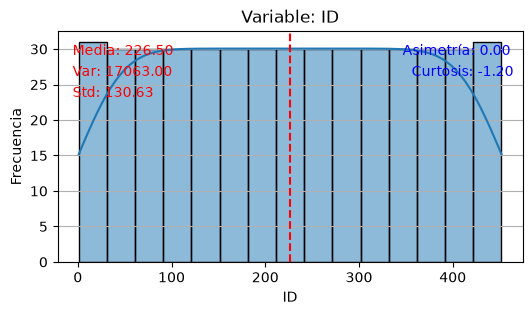

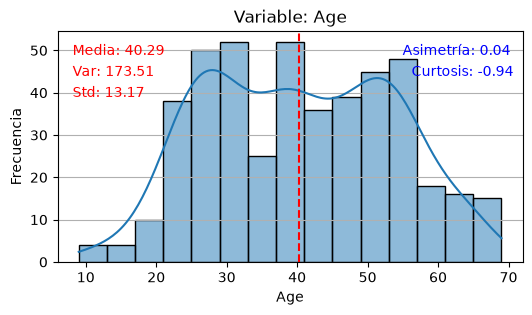

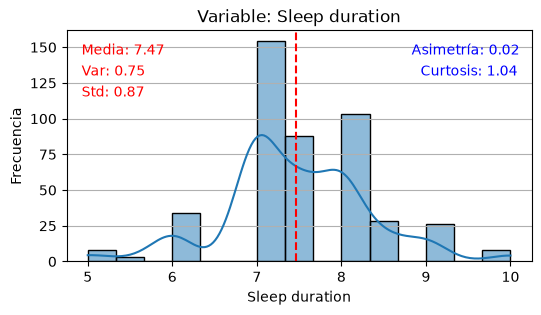

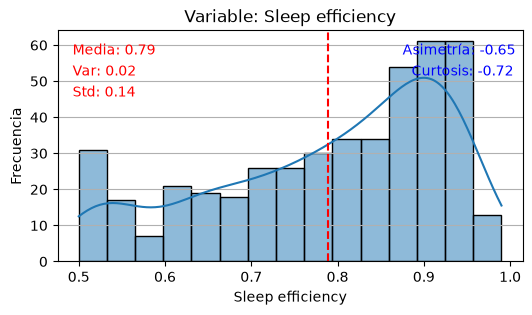

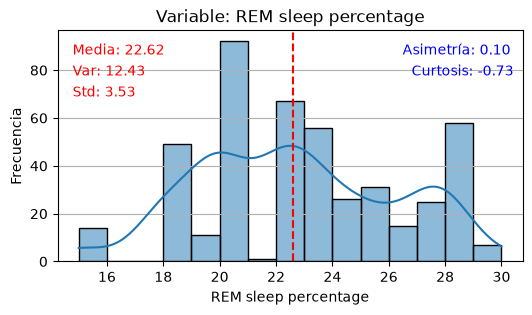

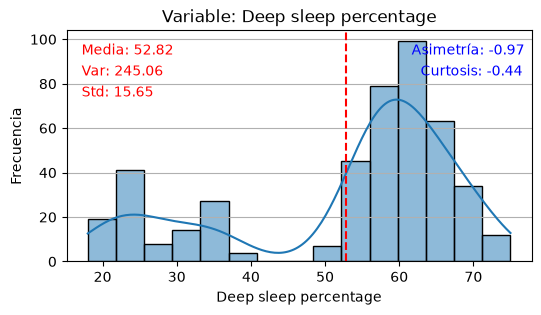

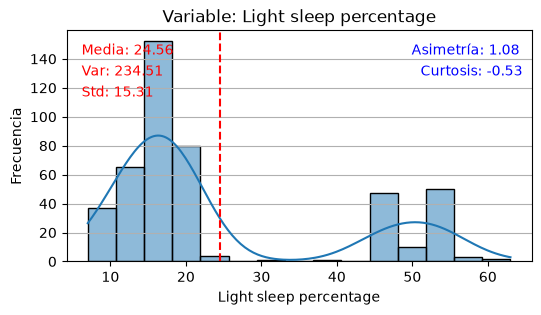

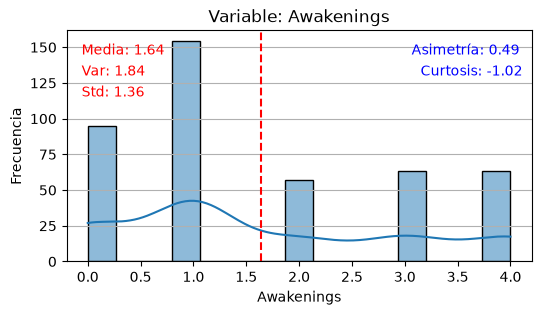

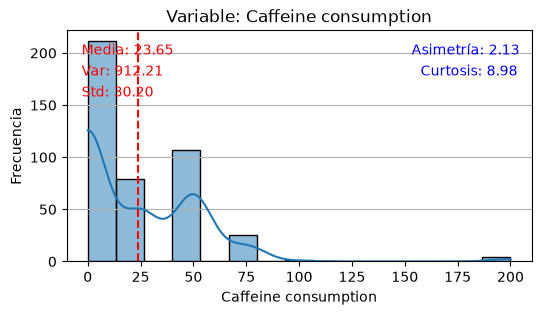

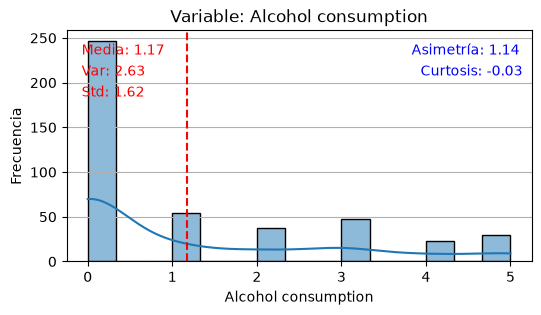

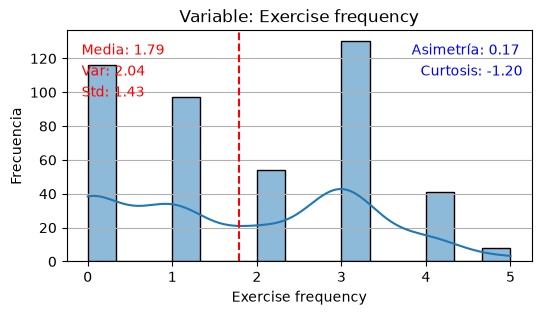

In [17]:
for v in var_numericas:
    plot_histograma(df, v, snk=True)

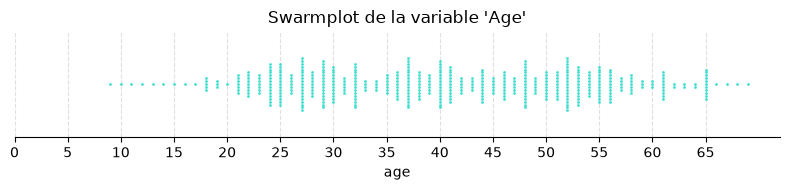

In [79]:
plt.figure(figsize=(8, 2))
sns.swarmplot(x=df['Age'], color='turquoise', size=2)

ax = plt.gca()
ax.set_xticks(np.arange(0, int(df['Age'].max()) + 1, 5))
ax.grid(axis='x', which='major', linestyle='--', alpha=0.4)
ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("age")
sns.despine(left=True)

plt.title(f"Swarmplot de la variable 'Age'")
plt.tight_layout()
plt.show()

## KDE - Gender vs Sleep Duration

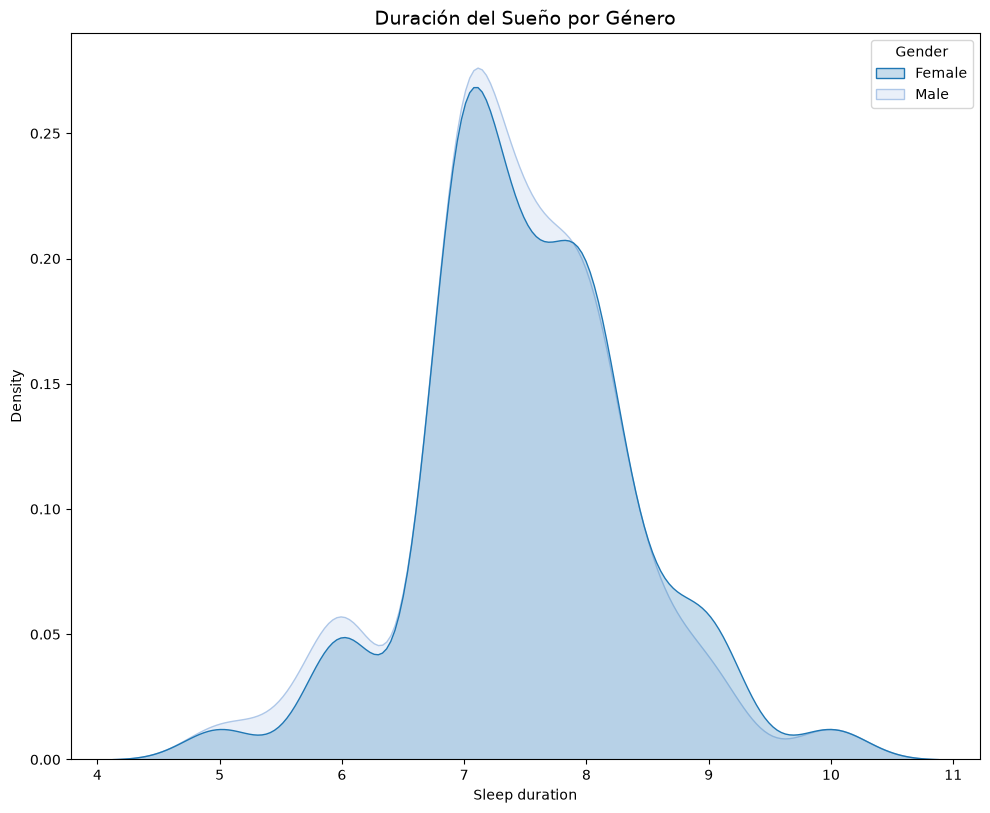

In [18]:
plt.figure(figsize=(10, 8))

sns.kdeplot(data=df, x='Sleep duration', hue='Gender', fill=True,
            palette='tab20')
plt.tight_layout()
plt.title('Duración del Sueño por Género', fontsize=14)
plt.show()

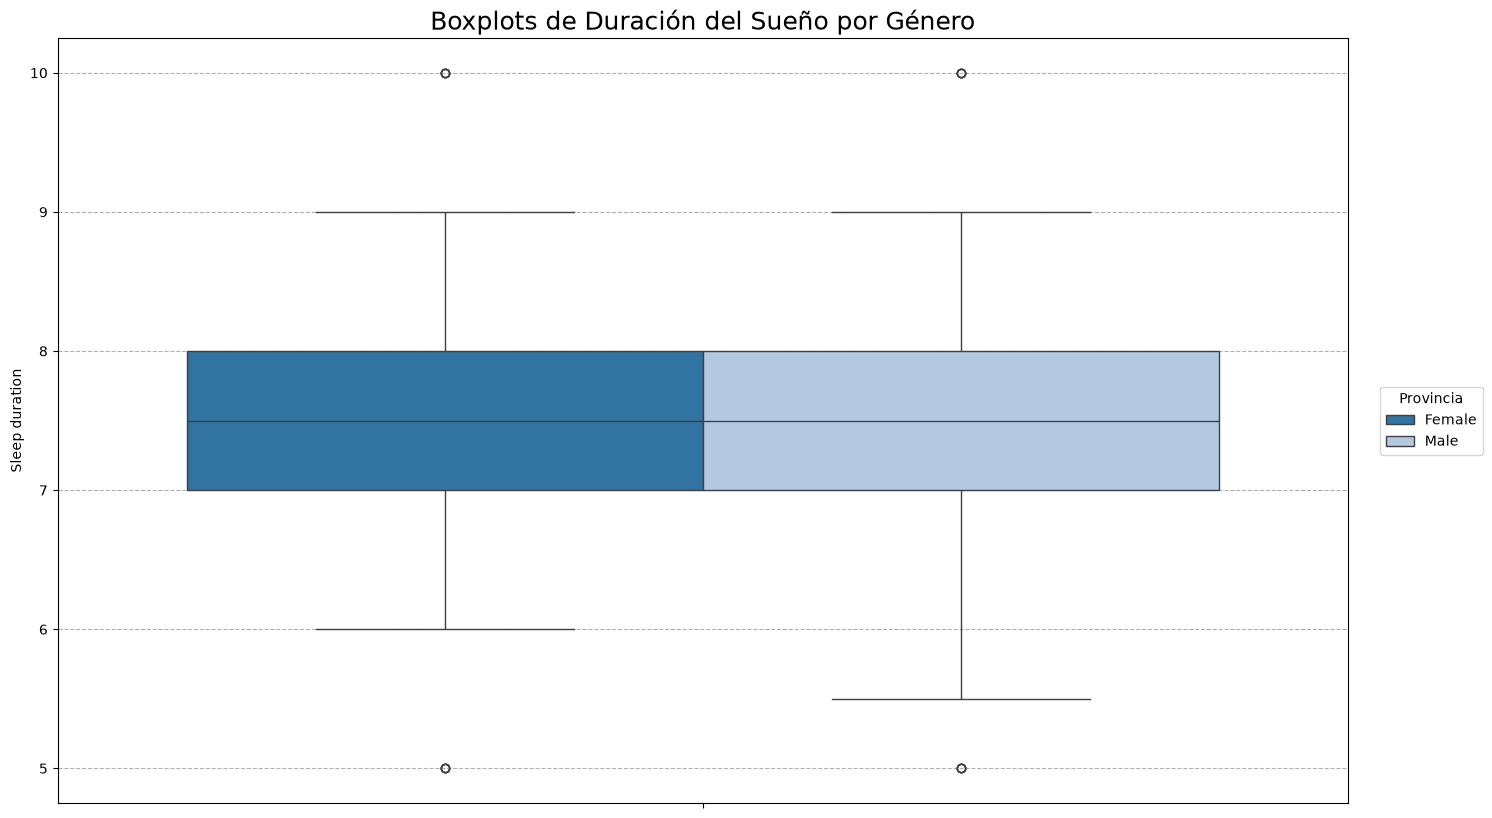

In [19]:
fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(data=df, y='Sleep duration', hue='Gender', ax=ax,
            palette='tab20')         # con seaborn-0.13.2

ax.grid(axis='y', ls='--')

ax.legend(
    title='Provincia',
    loc='center left',            # ancla en el centro a la izquierda del bbox
    bbox_to_anchor=(1.02, 0.5)    # x=1.02 (a la derecha del gráfico), y=0.5 (centrada verticalmente)
)
plt.tight_layout()
plt.title('Boxplots de Duración del Sueño por Género', fontsize=18)
plt.show()

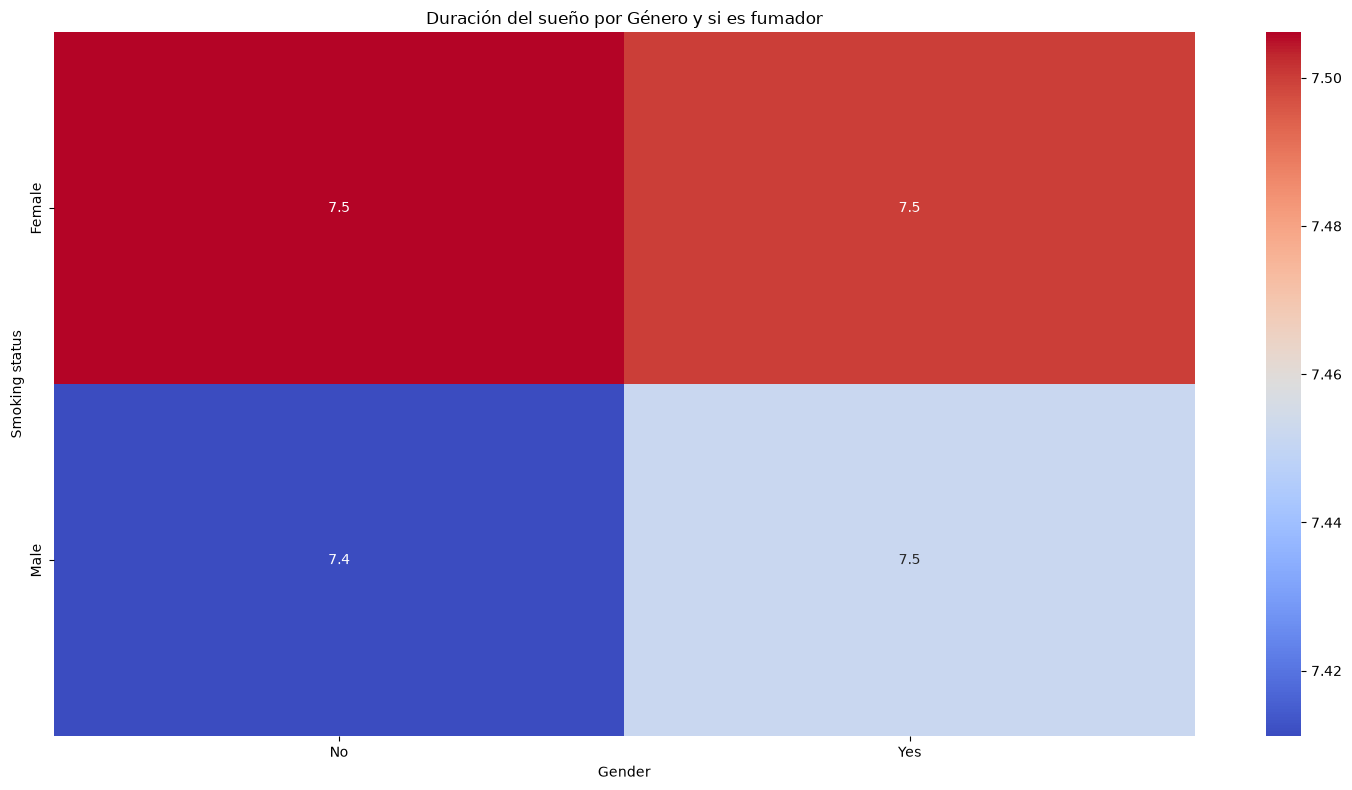

In [20]:
# obtener latitud promedio por provincia
orden_lat = (
    df
    .groupby('Gender', observed=False)['Sleep duration']
    .mean()
    .sort_values(ascending=False)
)

# crear tabla pivote
tabla = df.pivot_table(
    index='Gender',
    columns='Smoking status',
    values='Sleep duration',
    aggfunc='mean',
    observed=False
)

# reordenar filas según latitud
tabla = tabla.loc[orden_lat.index]

# heatmap
plt.figure(figsize=(15, 8))
sns.heatmap(tabla, cmap='coolwarm', annot=True, fmt=".1f")

plt.title('Duración del sueño por Género y si es fumador')
plt.xlabel('Gender')
plt.ylabel('Smoking status')
plt.tight_layout()
plt.show()


# Relación entre variables numericas

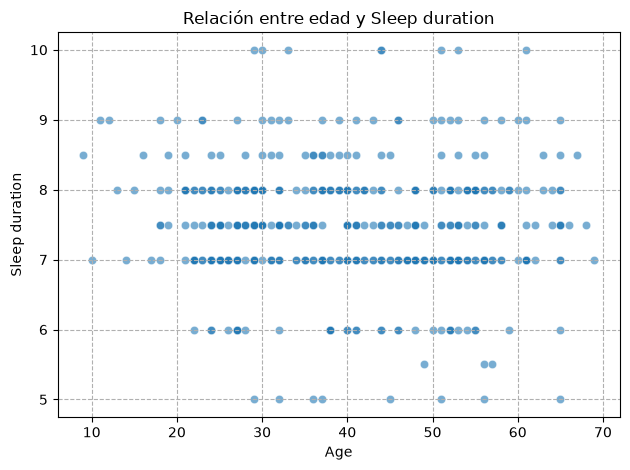

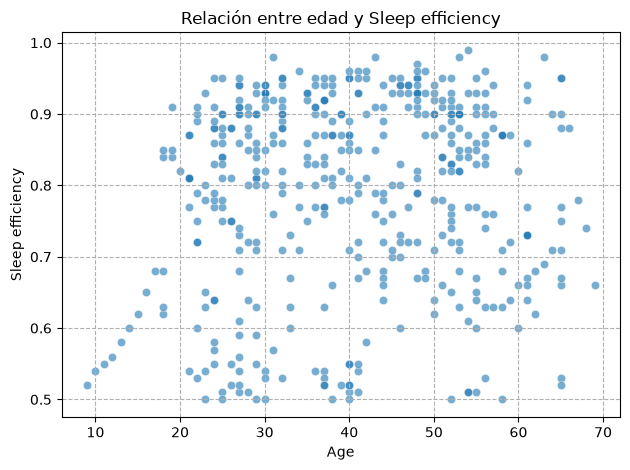

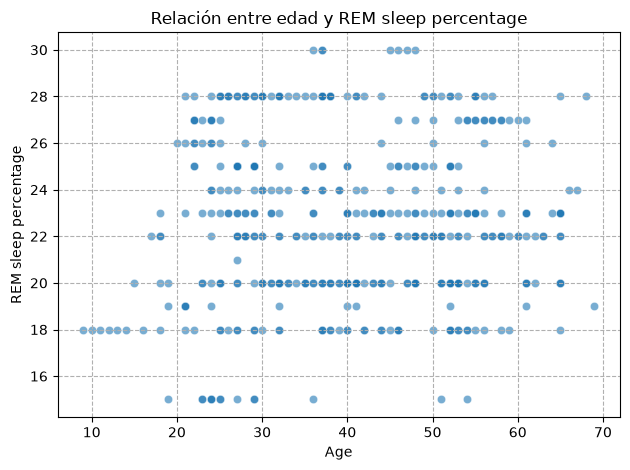

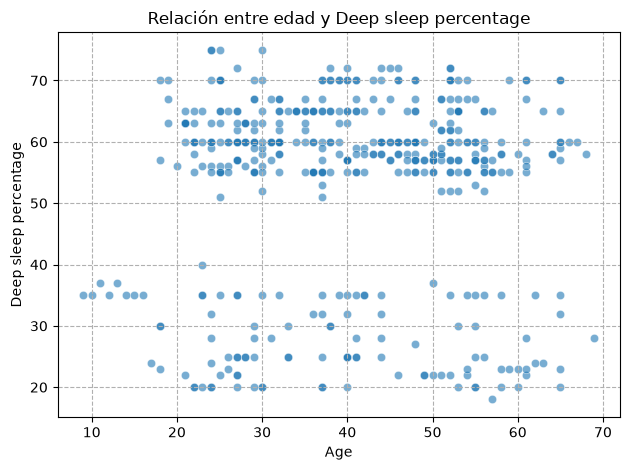

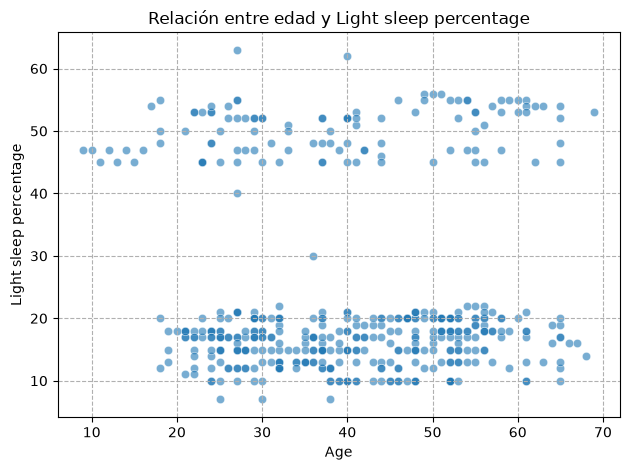

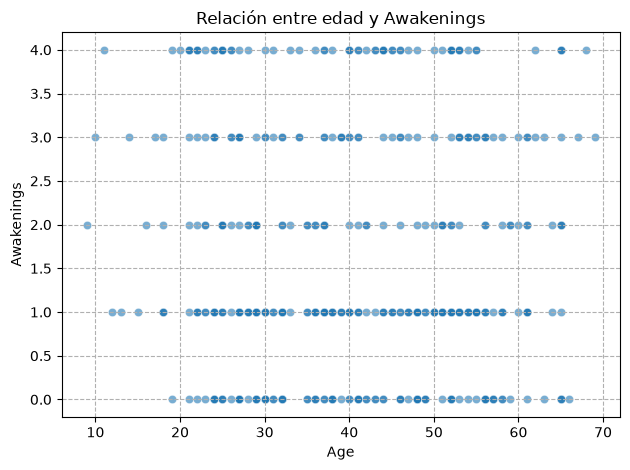

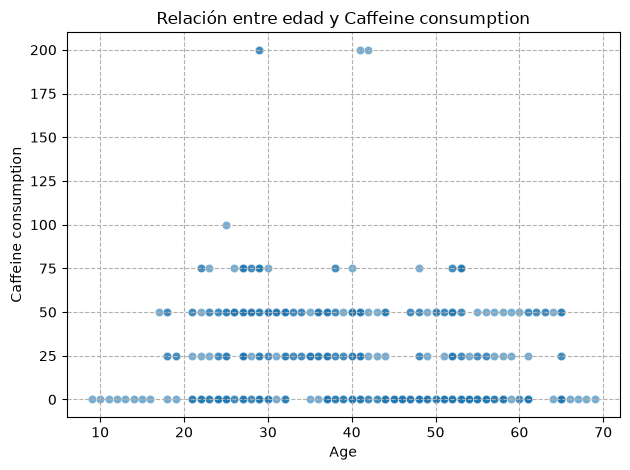

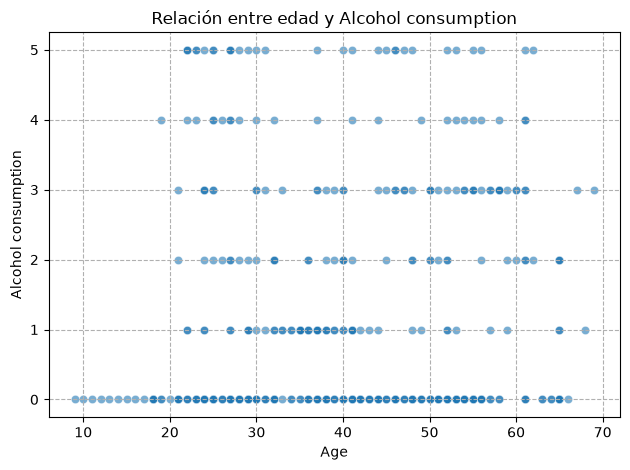

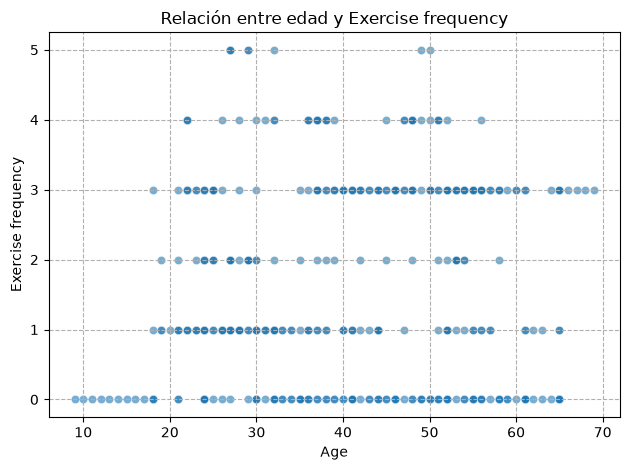

In [81]:
v1 = 'Age'

for v2 in var_numericas:
    if v2 == 'Age' or v2 == 'ID': continue
    sns.scatterplot(data=df, x=v1, y=v2, alpha=0.6)
    plt.grid(ls='--')
    plt.title(f'Relación entre edad y {v2}')
    plt.tight_layout()
    plt.show()    
        



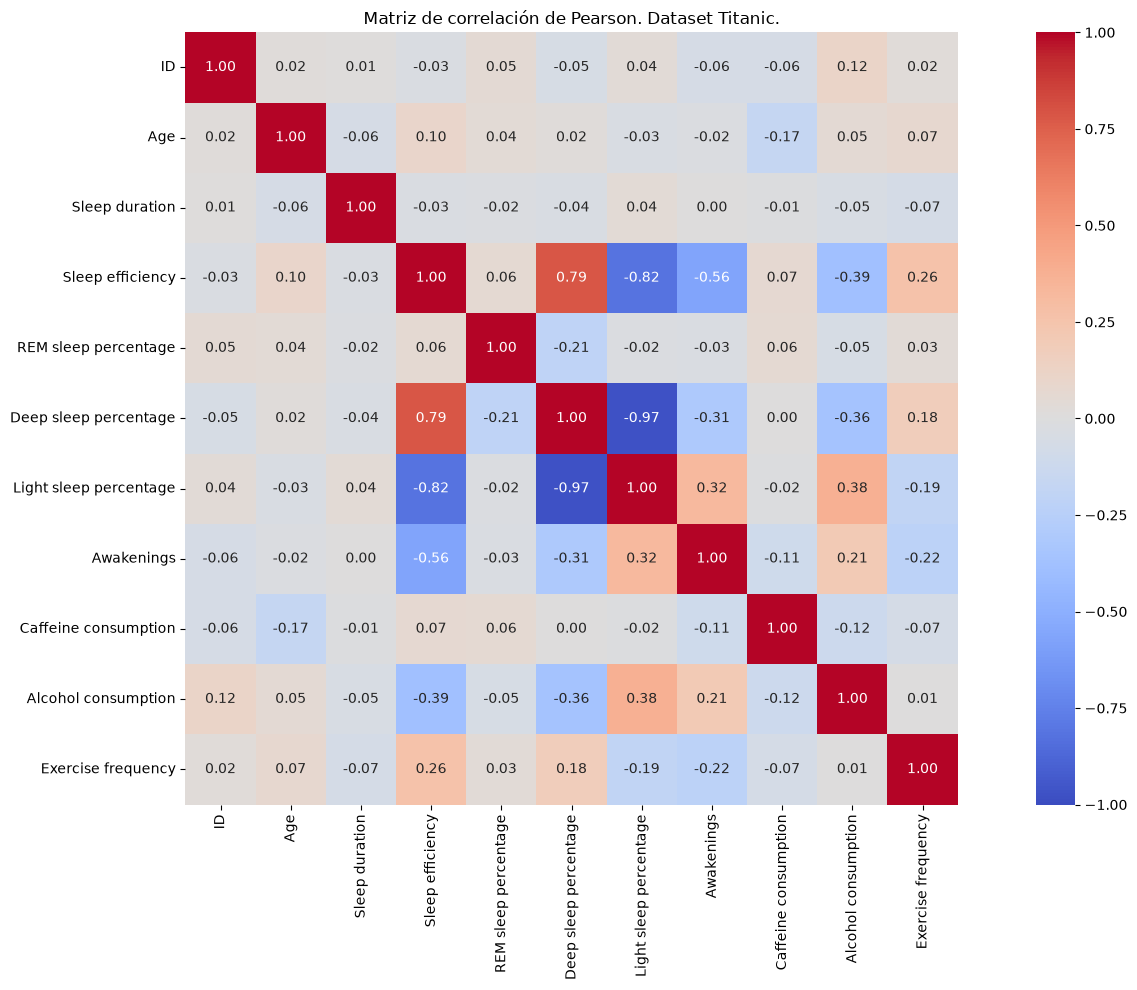

In [83]:
# Opción 1: mostrar toda la matriz de correlación como sale
corr_matrix = df[var_numericas].corr()
plt.figure(figsize=(16, 10))
# Heatmap
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            vmin=-1, vmax=1, center=0, square=True)
plt.title('Matriz de correlación de Pearson. Dataset Titanic.')
plt.tight_layout()
plt.show()

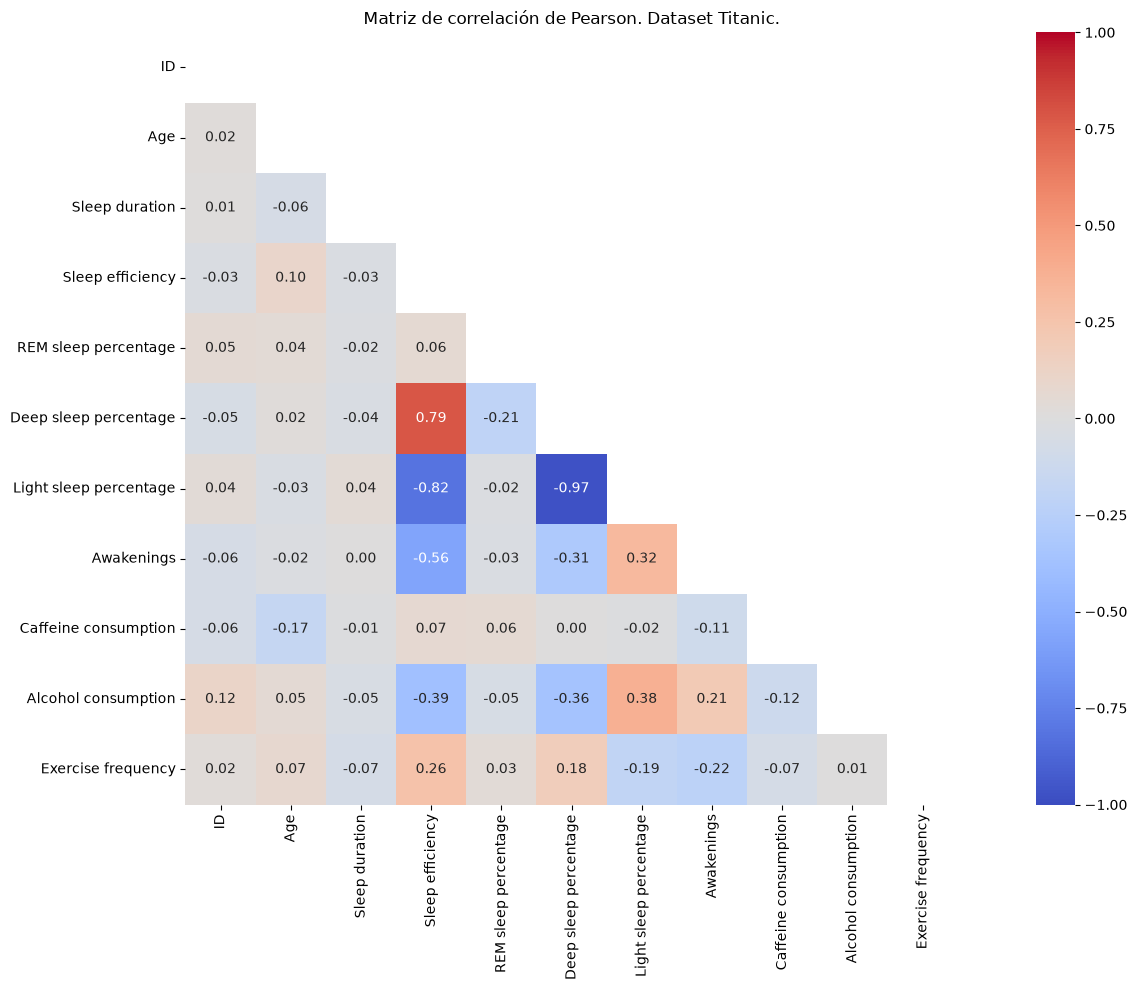

In [103]:
# Opción 2: si no queremos ver información redundante

# Creamos una máscara para ocultar la mitad superior de la matriz
mascara = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, square=True, mask=mascara) # Se filtra aplicando una máscara
plt.title('Matriz de correlación de Pearson. Dataset Titanic.')
plt.tight_layout()
plt.show()

## Numéricas-categóricas

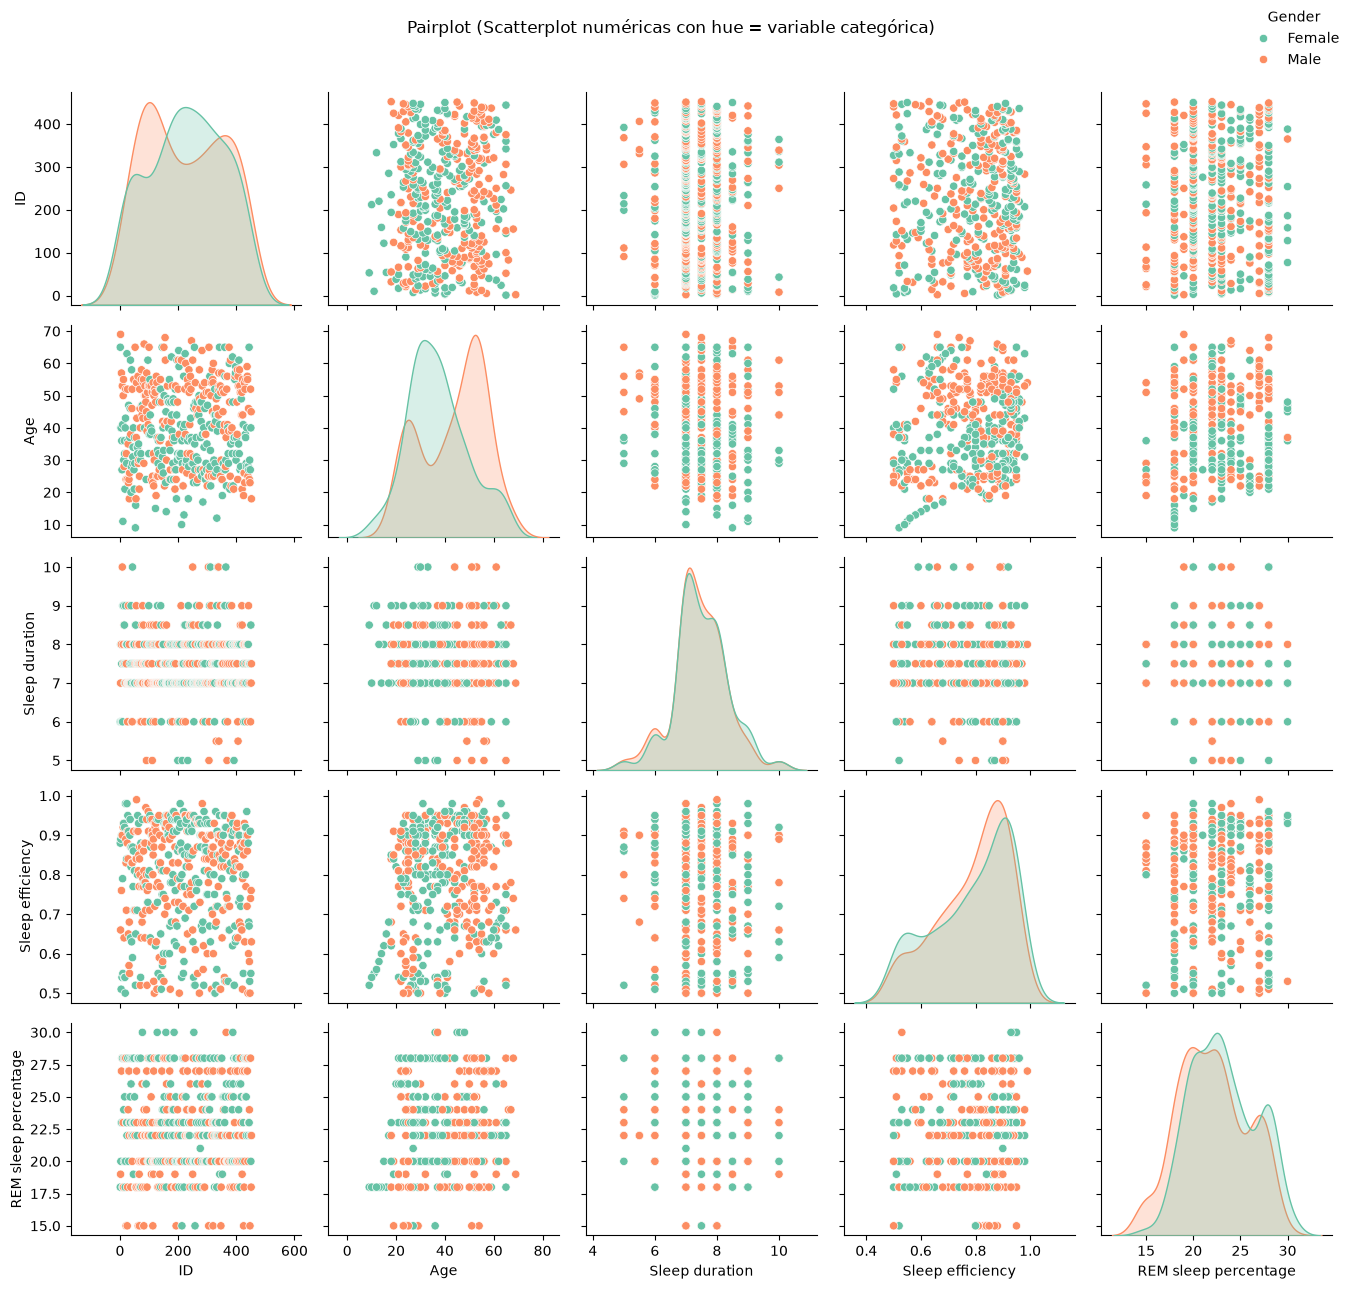

In [110]:
var_index = list(var_numericas[:len(var_numericas)//2])
var_index.append('Gender')


grafico = sns.pairplot(data=df[var_index], hue='Gender', palette='Set2')
grafico.figure.suptitle('Pairplot (Scatterplot numéricas con hue = variable categórica)', y=1.02) # Hago todo esto para que me muestre el título del gráfico, porque con pairplot no funciona plt.title()

grafico.legend.set_bbox_to_anchor((1, 1))
grafico.legend.set_title('Gender')

plt.tight_layout()
plt.show()

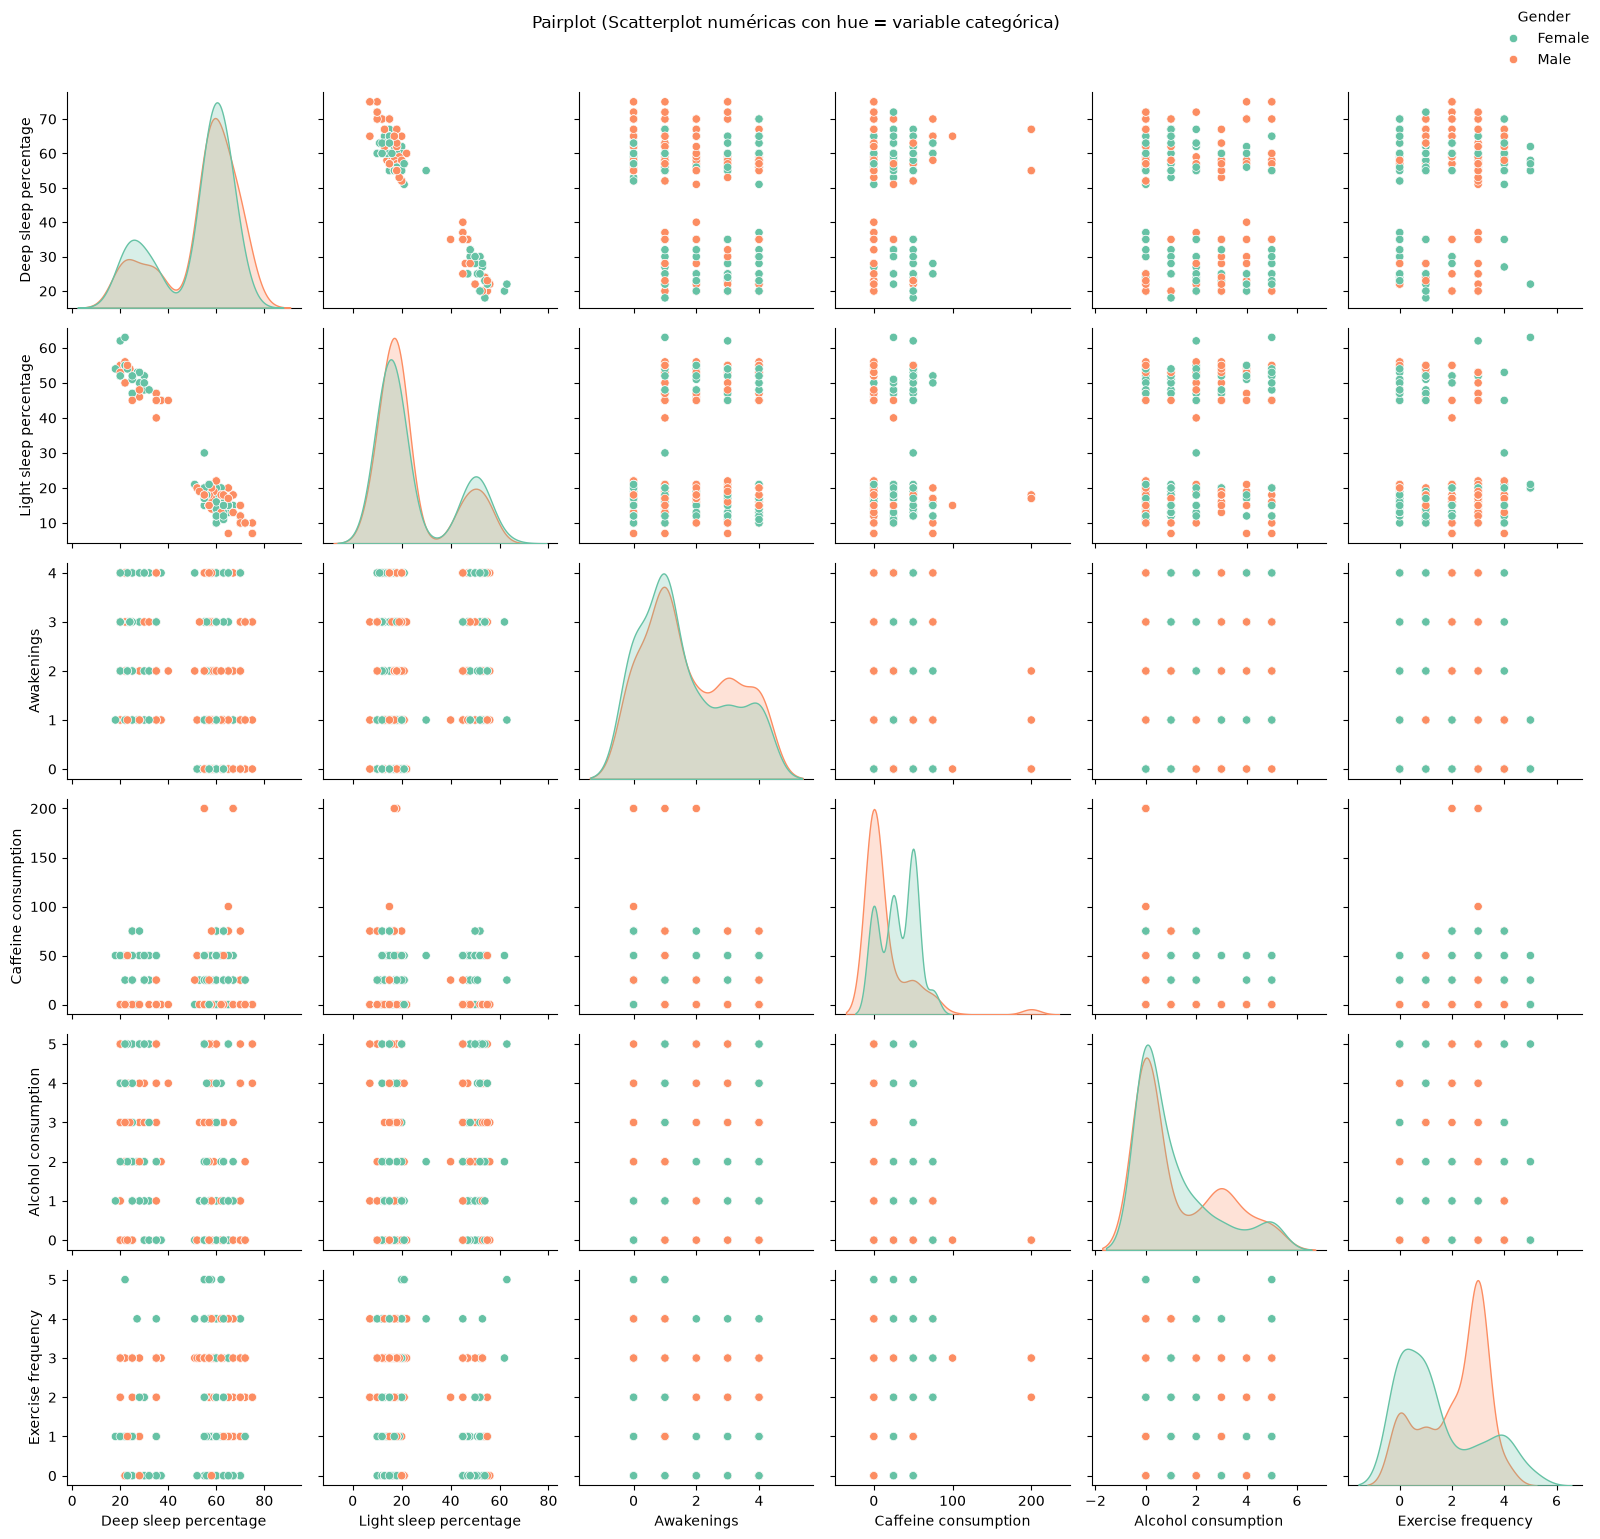

In [109]:
var_index = list(var_numericas[len(var_numericas)//2:])
var_index.append('Gender')


grafico = sns.pairplot(data=df[var_index], hue='Gender', palette='Set2')
grafico.figure.suptitle('Pairplot (Scatterplot numéricas con hue = variable categórica)', y=1.02) # Hago todo esto para que me muestre el título del gráfico, porque con pairplot no funciona plt.title()

grafico.legend.set_bbox_to_anchor((1, 1))
grafico.legend.set_title('Gender')

plt.tight_layout()
plt.show()

# Datos Faltantes

In [21]:
# Serie con los valores faltantes
faltantes = df.isna().sum()

# Calculamos porcentaje de valores faltantes
total_filas = len(df)
faltantes_df = faltantes.to_frame(name='faltantes')
faltantes_df['porcentaje'] = ((faltantes_df['faltantes'] / total_filas) * 100).round(2)
faltantes_df = faltantes_df.sort_values(by='faltantes', ascending=False)

# Mostramos solo las que tienen valores faltantes
faltantes_df[faltantes_df['faltantes'] > 0]

,faltantes,porcentaje
Caffeine consumption,25,5.53
Awakenings,20,4.42
Alcohol consumption,14,3.10
Exercise frequency,6,1.33


<Axes: >

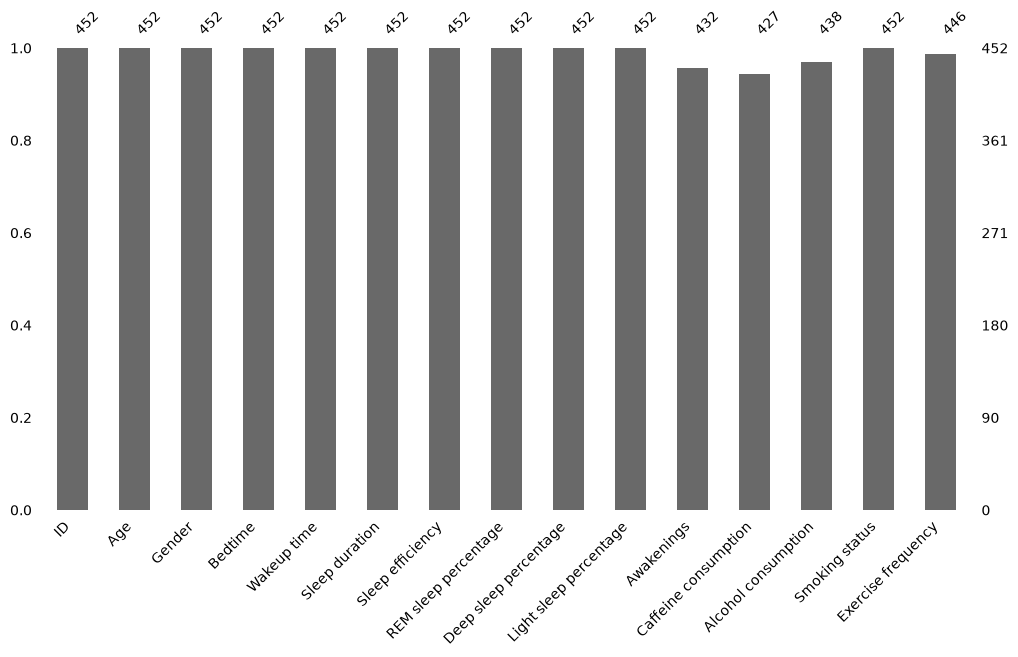

In [22]:
msno.bar(df, figsize=(12, 6), fontsize=10)

<Axes: >

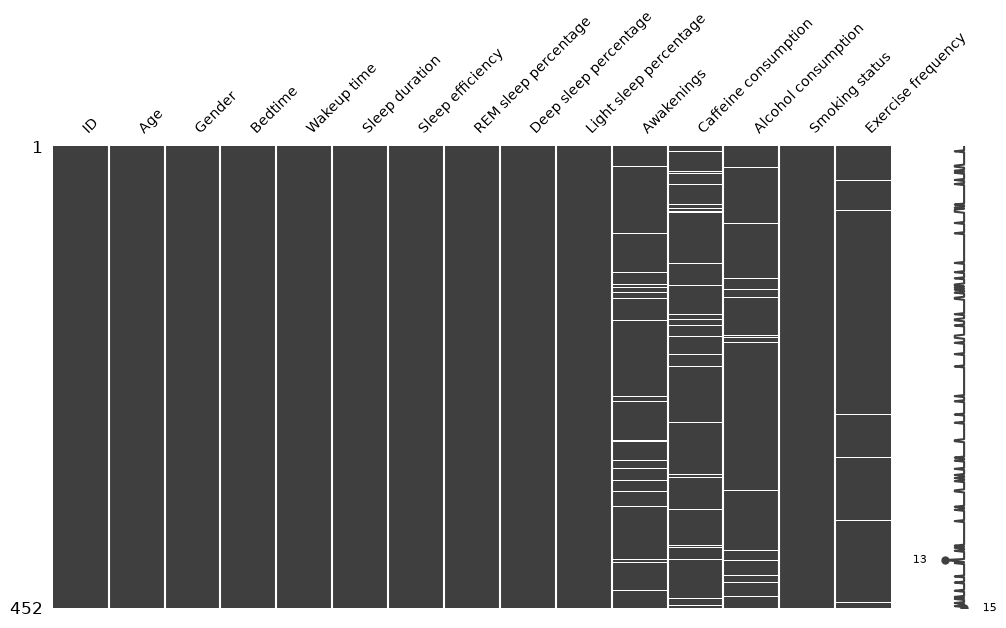

In [23]:
msno.matrix(df, figsize=(12, 6), sparkline=True, fontsize=10)

<Axes: >

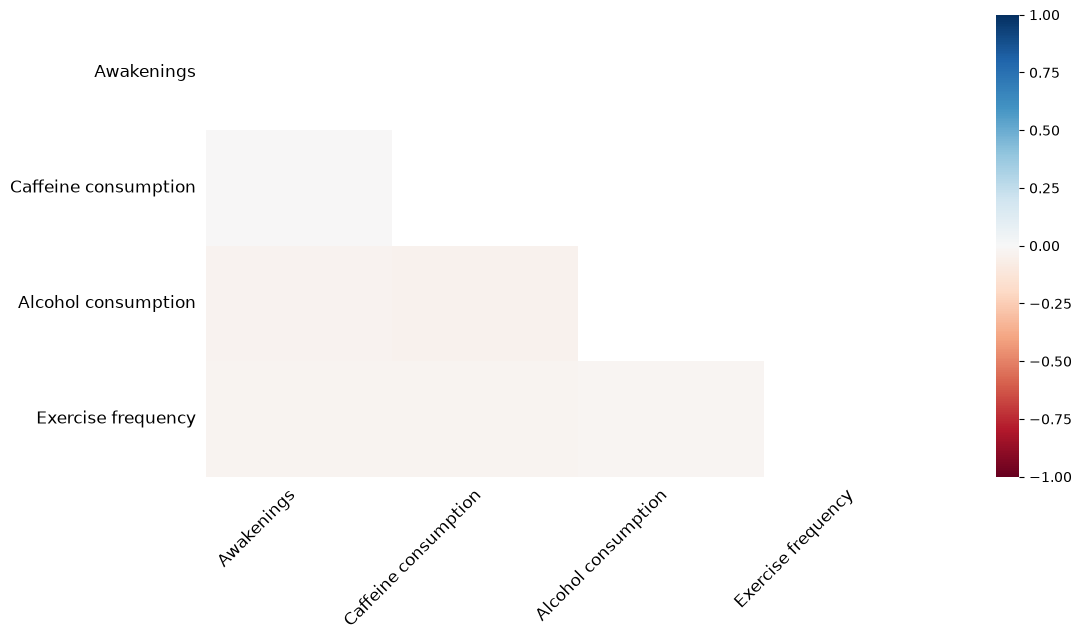

In [24]:
msno.heatmap(df, figsize=(12, 6), fontsize=12)

<Axes: >

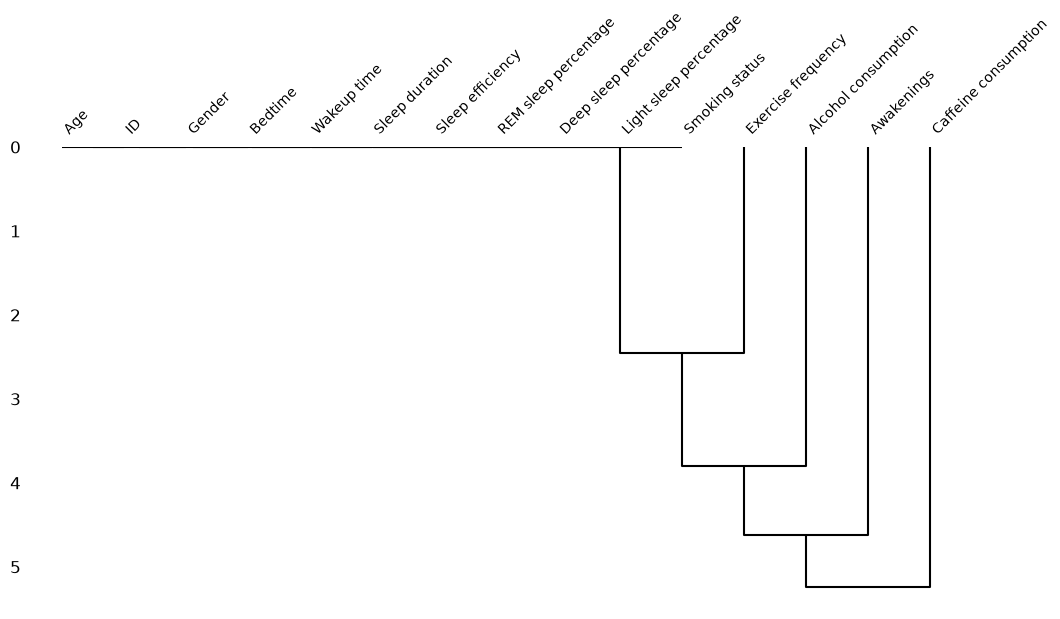

In [25]:
msno.dendrogram(df, figsize=(12, 6), fontsize=10)

In [29]:
# Creamos una función para calcular el porcentaje de nulos en una columna, agrupando por una o más columnas
def nulos_por_grupo(df, grupo_cols, target_col):
    agrupar_nulos = (
        df.groupby(grupo_cols, observed=True)[target_col]
        .apply(lambda x: x.isnull().mean() * 100)
        .reset_index(name=f'porcentaje_nulos_{target_col}')
    )

    return agrupar_nulos[agrupar_nulos[f'porcentaje_nulos_{target_col}'] > 0]

In [45]:
# Imprimo el % de nulos por categoría y Genero
grupo_nulo = list()
var_faltantes = faltantes_df['faltantes'].index


print(var_faltantes)
for v in var_faltantes:
    if faltantes_df['faltantes'][v] > 0:
        grupo_nulo.append(( ['Gender'], v))

for x, y in grupo_nulo:
    r = nulos_por_grupo(df,x,y)

    print(r.head(10))

Index(['Caffeine consumption', 'Awakenings', 'Alcohol consumption',
       'Exercise frequency', 'ID', 'Age', 'Gender', 'Sleep efficiency',
       'Sleep duration', 'Wakeup time', 'Bedtime', 'Light sleep percentage',
       'Deep sleep percentage', 'REM sleep percentage', 'Smoking status'],
      dtype='str')
   Gender  porcentaje_nulos_Caffeine consumption
0  Female                               5.803571
1    Male                               5.263158
   Gender  porcentaje_nulos_Awakenings
0  Female                     4.464286
1    Male                     4.385965
   Gender  porcentaje_nulos_Alcohol consumption
0  Female                              2.232143
1    Male                              3.947368
   Gender  porcentaje_nulos_Exercise frequency
0  Female                             0.892857
1    Male                             1.754386


# Outliers

In [46]:
df.describe()

,ID,Age,Sleep duration,Sleep efficiency,REM sleep percentage,Deep sleep percentage,Light sleep percentage,Awakenings,Caffeine consumption,Alcohol consumption,Exercise frequency
count,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,452.000000,432.000000,427.000000,438.000000,446.000000
mean,226.500000,40.285398,7.465708,0.788916,22.615044,52.823009,24.561947,1.641204,23.653396,1.173516,1.791480
std,130.625419,13.172250,0.866625,0.135237,3.525963,15.654235,15.313665,1.356762,30.202785,1.621377,1.428134
min,1.000000,9.000000,5.000000,0.500000,15.000000,18.000000,7.000000,0.000000,0.000000,0.000000,0.000000
25%,113.750000,29.000000,7.000000,0.697500,20.000000,48.250000,15.000000,1.000000,0.000000,0.000000,0.000000
50%,226.500000,40.000000,7.500000,0.820000,22.000000,58.000000,18.000000,1.000000,25.000000,0.000000,2.000000
75%,339.250000,52.000000,8.000000,0.900000,25.000000,63.000000,32.500000,3.000000,50.000000,2.000000,3.000000
max,452.000000,69.000000,10.000000,0.990000,30.000000,75.000000,63.000000,4.000000,200.000000,5.000000,5.000000


In [49]:
# Método  de rango intercuartil para detectar outliers
columnas = var_numericas
df_outliers = df[columnas]
            
Q1 = df_outliers.quantile(0.25)
Q3 = df_outliers.quantile(0.75)
IQR = Q3 - Q1

# Crea un diccionario con los límites inferior y superior de cada variable
outlier_limits = {
    col: (Q1[col] - 1.5 * IQR[col], Q3[col] + 1.5 * IQR[col])
    for col in df_outliers.columns
}
outlier_limits

{'ID': (np.float64(-224.5), np.float64(677.5)),
 'Age': (np.float64(-5.5), np.float64(86.5)),
 'Sleep duration': (np.float64(5.5), np.float64(9.5)),
 'Sleep efficiency': (np.float64(0.39375), np.float64(1.20375)),
 'REM sleep percentage': (np.float64(12.5), np.float64(32.5)),
 'Deep sleep percentage': (np.float64(26.125), np.float64(85.125)),
 'Light sleep percentage': (np.float64(-11.25), np.float64(58.75)),
 'Awakenings': (np.float64(-2.0), np.float64(6.0)),
 'Caffeine consumption': (np.float64(-75.0), np.float64(125.0)),
 'Alcohol consumption': (np.float64(-3.0), np.float64(5.0)),
 'Exercise frequency': (np.float64(-4.5), np.float64(7.5))}

## Boxplots

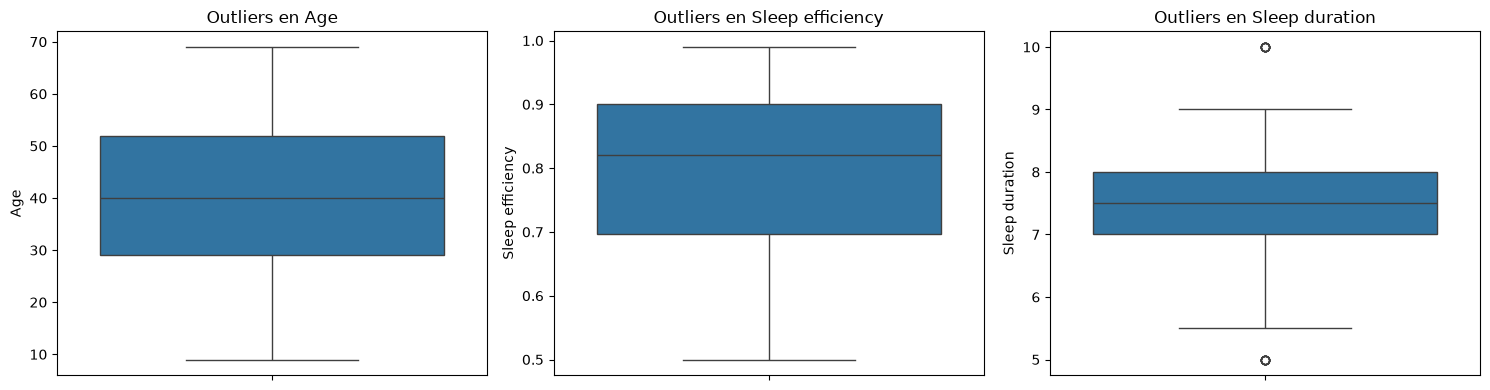

In [66]:


def plot_out_3(var_out):
    n = len(var_out)
    fig, axes = plt.subplots(1, n, figsize=(15, 4))
    

    if n == 1:
        sns.boxplot(y=df[var_out[0]], ax=axes)
        axes.set_title(f'Outliers en {var_out[0]}')
    else:
        for i in range(n):
            sns.boxplot(y=df[var_out[i]], ax=axes[i])
            axes[i].set_title(f'Outliers en {var_out[i]}')
    
    
    plt.tight_layout()
    plt.show()

plot_out_3(['Age', 'Sleep efficiency', 'Sleep duration' ])

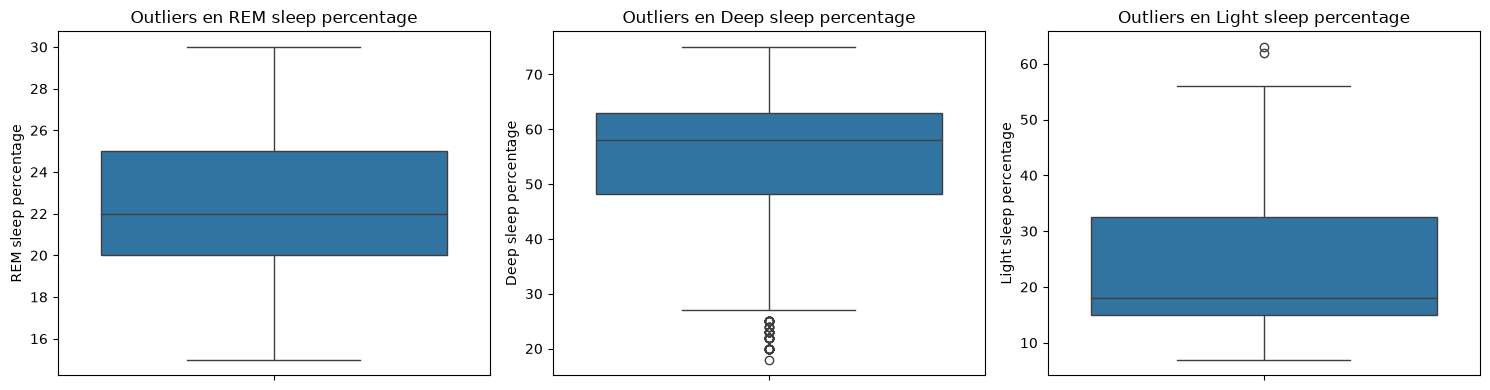

In [56]:

plot_out_3(['REM sleep percentage',
    'Deep sleep percentage',
    'Light sleep percentage' ])

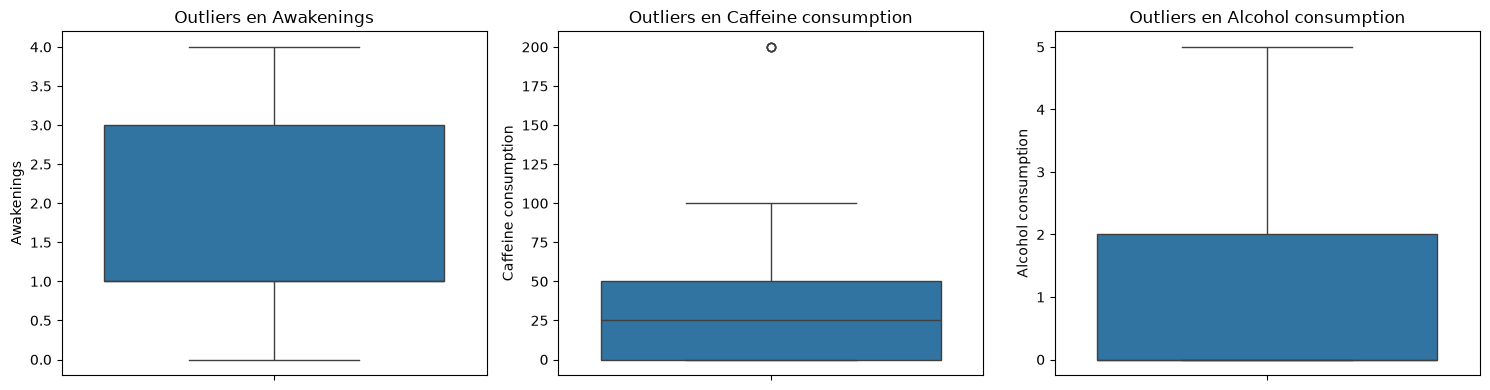

In [57]:
plot_out_3(['Awakenings',
    'Caffeine consumption',
    'Alcohol consumption'])

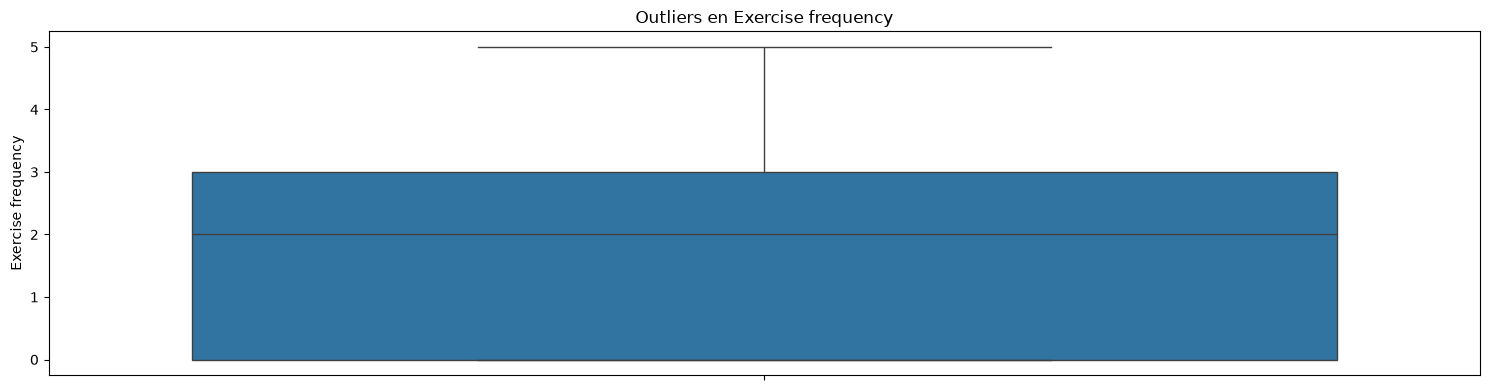

In [67]:
plot_out_3(['Exercise frequency'])

# Analisis de Outliers

In [71]:
#columnas = ['temp', 'temp_max', 'temp_min']
mean = df[columnas].mean()
std = df[columnas].apply(lambda x: np.nanstd(x, ddof=1))

In [77]:
def plot_hist_with_std(ax, data, varname, mean, std):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mean[varname] - 3*std[varname], color='red', linestyle='--', label='Mean - 3*STD')
    ax.axvline(mean[varname] + 3*std[varname], color='green', linestyle='--', label='Mean + 3*STD')
    ax.set_xlabel(varname.capitalize())
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Histograma de {varname.capitalize()} ±3 SD')
    ax.legend()

def plot_all_hist(var_list):
    n = len(var_list)
    fig, ax = plt.subplots(1, n, figsize=(12, 4))

    if n == 1: 
        plot_hist_with_std(ax, df[var_list[0]], var_list[0], mean, std)
        
    else:
        for i in range(n):
            plot_hist_with_std(ax[i], df[var_list[i]], var_list[i], mean, std)
        
    plt.tight_layout()
    plt.show()

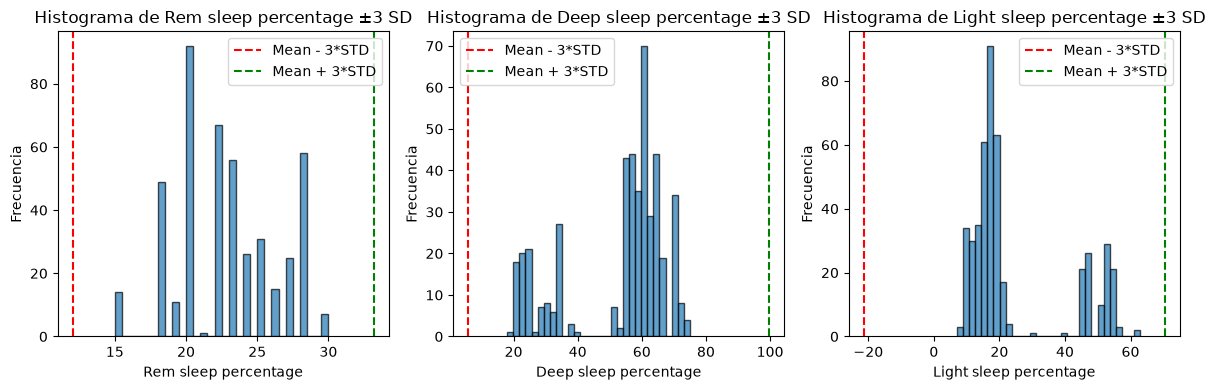

In [78]:
plot_all_hist(['REM sleep percentage','Deep sleep percentage','Light sleep percentage'])